# Sprint 12: Numerical Methods

Rusty Bargain used car sales service is developing an app to attract new customers. In that app, you can quickly find out the market value of your car. You have access to historical data: technical specifications, trim versions, and prices. You need to build the model to determine the value.

Rusty Bargain is interested in:
- the quality of the prediction;
- the speed of the prediction;
- the time required for training

## Data preparation

In [1]:
import pandas as pd 
import numpy as np 
import time

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error 
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, SGDRegressor

from catboost import CatBoostRegressor, Pool
import lightgbm as ltb 
import xgboost as xg

In [2]:
#df = pd.read_csv('/datasets/car_data.csv')
df = pd.read_csv('https://code.s3.yandex.net/datasets/car_data.csv')
df_initial_size = df.shape[0]

df.sample(5)

,DateCrawled,Price,VehicleType,RegistrationYear,Gearbox,Power,Model,Mileage,RegistrationMonth,FuelType,Brand,NotRepaired,DateCreated,NumberOfPictures,PostalCode,LastSeen
89753,05/03/2016 20:58,1500,wagon,2004,manual,116,stilo,150000,4,gasoline,fiat,no,05/03/2016 00:00,0,74731,01/04/2016 18:19
208335,23/03/2016 19:42,19000,coupe,2010,manual,179,a5,90000,2,petrol,audi,no,23/03/2016 00:00,0,95615,06/04/2016 00:17
316882,27/03/2016 22:51,0,sedan,1999,manual,101,golf,150000,0,petrol,volkswagen,yes,27/03/2016 00:00,0,34466,28/03/2016 00:42
320310,23/03/2016 14:39,11990,small,2015,manual,86,fabia,20000,2,petrol,skoda,no,23/03/2016 00:00,0,31552,05/04/2016 15:18
181094,03/04/2016 09:52,2850,wagon,2003,manual,109,3_reihe,125000,9,petrol,peugeot,no,03/04/2016 00:00,0,33729,07/04/2016 11:17


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 354369 entries, 0 to 354368
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   DateCrawled        354369 non-null  object
 1   Price              354369 non-null  int64 
 2   VehicleType        316879 non-null  object
 3   RegistrationYear   354369 non-null  int64 
 4   Gearbox            334536 non-null  object
 5   Power              354369 non-null  int64 
 6   Model              334664 non-null  object
 7   Mileage            354369 non-null  int64 
 8   RegistrationMonth  354369 non-null  int64 
 9   FuelType           321474 non-null  object
 10  Brand              354369 non-null  object
 11  NotRepaired        283215 non-null  object
 12  DateCreated        354369 non-null  object
 13  NumberOfPictures   354369 non-null  int64 
 14  PostalCode         354369 non-null  int64 
 15  LastSeen           354369 non-null  object
dtypes: int64(7), object(

In [4]:
df.describe()

,Price,RegistrationYear,Power,Mileage,RegistrationMonth,NumberOfPictures,PostalCode
count,354369.000000,354369.000000,354369.000000,354369.000000,354369.000000,354369.0,354369.000000
mean,4416.656776,2004.234448,110.094337,128211.172535,5.714645,0.0,50508.689087
std,4514.158514,90.227958,189.850405,37905.341530,3.726421,0.0,25783.096248
min,0.000000,1000.000000,0.000000,5000.000000,0.000000,0.0,1067.000000
25%,1050.000000,1999.000000,69.000000,125000.000000,3.000000,0.0,30165.000000
50%,2700.000000,2003.000000,105.000000,150000.000000,6.000000,0.0,49413.000000
75%,6400.000000,2008.000000,143.000000,150000.000000,9.000000,0.0,71083.000000
max,20000.000000,9999.000000,20000.000000,150000.000000,12.000000,0.0,99998.000000


In [5]:
df.isna().sum()

DateCrawled              0
Price                    0
VehicleType          37490
RegistrationYear         0
Gearbox              19833
Power                    0
Model                19705
Mileage                  0
RegistrationMonth        0
FuelType             32895
Brand                    0
NotRepaired          71154
DateCreated              0
NumberOfPictures         0
PostalCode               0
LastSeen                 0
dtype: int64

In [6]:
df.isna().sum()/df.shape[0]*100

DateCrawled           0.000000
Price                 0.000000
VehicleType          10.579368
RegistrationYear      0.000000
Gearbox               5.596709
Power                 0.000000
Model                 5.560588
Mileage               0.000000
RegistrationMonth     0.000000
FuelType              9.282697
Brand                 0.000000
NotRepaired          20.079070
DateCreated           0.000000
NumberOfPictures      0.000000
PostalCode            0.000000
LastSeen              0.000000
dtype: float64

Columns `Gearbox` & `Model` have a low percentage of null values

### Preprocessing

In [7]:
df.loc[:,['DateCrawled', 'DateCreated', 'LastSeen','RegistrationYear']].head()

,DateCrawled,DateCreated,LastSeen,RegistrationYear
0,24/03/2016 11:52,24/03/2016 00:00,07/04/2016 03:16,1993
1,24/03/2016 10:58,24/03/2016 00:00,07/04/2016 01:46,2011
2,14/03/2016 12:52,14/03/2016 00:00,05/04/2016 12:47,2004
3,17/03/2016 16:54,17/03/2016 00:00,17/03/2016 17:40,2001
4,31/03/2016 17:25,31/03/2016 00:00,06/04/2016 10:17,2008


In [8]:
for col in ['DateCrawled', 'DateCreated', 'LastSeen']:
    df[col] = pd.to_datetime(df[col], dayfirst=True)

In [9]:
# keep only the year of the columns with a date
for col in ['DateCrawled', 'DateCreated', 'LastSeen']:
    df[col] = pd.DatetimeIndex(df[col]).year 

df.head()

,DateCrawled,Price,VehicleType,RegistrationYear,Gearbox,Power,Model,Mileage,RegistrationMonth,FuelType,Brand,NotRepaired,DateCreated,NumberOfPictures,PostalCode,LastSeen
0,2016,480,NaN,1993,manual,0,golf,150000,0,petrol,volkswagen,NaN,2016,0,70435,2016
1,2016,18300,coupe,2011,manual,190,NaN,125000,5,gasoline,audi,yes,2016,0,66954,2016
2,2016,9800,suv,2004,auto,163,grand,125000,8,gasoline,jeep,NaN,2016,0,90480,2016
3,2016,1500,small,2001,manual,75,golf,150000,6,petrol,volkswagen,no,2016,0,91074,2016
4,2016,3600,small,2008,manual,69,fabia,90000,7,gasoline,skoda,no,2016,0,60437,2016


In [10]:
#drop unnecessary column
df = df.drop('NumberOfPictures',axis=1)

In [11]:
# drop null values
df = df.dropna(subset=['Gearbox','Model'])

In [12]:
df.isna().sum()/df.shape[0]*100

DateCrawled           0.000000
Price                 0.000000
VehicleType           7.431606
RegistrationYear      0.000000
Gearbox               0.000000
Power                 0.000000
Model                 0.000000
Mileage               0.000000
RegistrationMonth     0.000000
FuelType              6.186944
Brand                 0.000000
NotRepaired          16.529555
DateCreated           0.000000
PostalCode            0.000000
LastSeen              0.000000
dtype: float64

**Null values in `VehicleType`**

In [13]:
df[df['VehicleType'].isna()].head()

,DateCrawled,Price,VehicleType,RegistrationYear,Gearbox,Power,Model,Mileage,RegistrationMonth,FuelType,Brand,NotRepaired,DateCreated,PostalCode,LastSeen
0,2016,480,NaN,1993,manual,0,golf,150000,0,petrol,volkswagen,NaN,2016,70435,2016
22,2016,2900,NaN,2018,manual,90,meriva,150000,5,petrol,opel,no,2016,49716,2016
26,2016,5555,NaN,2017,manual,125,c4,125000,4,NaN,citroen,no,2016,31139,2016
31,2016,899,NaN,2016,manual,60,clio,150000,6,petrol,renault,NaN,2016,37075,2016
35,2016,350,NaN,2016,manual,75,golf,150000,4,petrol,volkswagen,no,2016,19386,2016


In [14]:
df['VehicleType'].sort_values().unique()

array(['bus', 'convertible', 'coupe', 'other', 'sedan', 'small', 'suv',
       'wagon', nan], dtype=object)

In [15]:
df['VehicleType'].sort_values().value_counts()

VehicleType
sedan          85937
small          73614
wagon          61436
bus            27081
convertible    18722
coupe          14851
suv            10959
other           2658
Name: count, dtype: int64

In [16]:
#top 11 models without Vehicle Type
df[df['VehicleType'].isna()]['Model'].value_counts().head(11)

Model
golf        3266
other       1213
polo        1182
corsa       1162
3er         1048
astra        966
a3           675
passat       537
twingo       477
a_klasse     467
fiesta       465
Name: count, dtype: int64

In [17]:
# Vehicle Type mode per Model
model_mode = df.groupby('Model')['VehicleType'].agg(pd.Series.mode)

for vtype in ['golf', 'polo', 'corsa', '3er', 'astra','a3','passat','twingo','a_klasse','fiesta']:
    print (vtype,':',model_mode[vtype])

golf : sedan
polo : small
corsa : small
3er : sedan
astra : sedan
a3 : sedan
passat : wagon
twingo : small
a_klasse : sedan
fiesta : small


In [18]:
# fill with mode per group
df['VehicleType'] = np.where(
    (df['VehicleType'].isna()==True) & (df['Model'].isin(['golf','3er','astra','a3','a_klasse'])),'sedan',
    np.where((df['VehicleType'].isna()==True) & (df['Model'].isin(['polo','corsa','twingo'])),'small',
    np.where((df['VehicleType'].isna()==True) & (df['Model'] == 'passat')                    ,'wagon','other')))

# verify changes
df[df['VehicleType'].isna()].value_counts()

Series([], Name: count, dtype: int64)

**Null values in `FuelType`**

In [19]:
df['FuelType'].value_counts()

FuelType
petrol      200925
gasoline     92547
lpg           4854
cng            531
hybrid         203
other          108
electric        60
Name: count, dtype: int64

In [20]:
df['FuelType'] = df['FuelType'].fillna('unknown')

**Null values in `NotRepaired`**

In [21]:
df['NotRepaired'].value_counts()

NotRepaired
no     233822
yes     32417
Name: count, dtype: int64

Most cars have not been repaired.

In [22]:
df['NotRepaired'] = df['NotRepaired'].fillna('no')

# verify changes
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 318962 entries, 0 to 354368
Data columns (total 15 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   DateCrawled        318962 non-null  int32 
 1   Price              318962 non-null  int64 
 2   VehicleType        318962 non-null  object
 3   RegistrationYear   318962 non-null  int64 
 4   Gearbox            318962 non-null  object
 5   Power              318962 non-null  int64 
 6   Model              318962 non-null  object
 7   Mileage            318962 non-null  int64 
 8   RegistrationMonth  318962 non-null  int64 
 9   FuelType           318962 non-null  object
 10  Brand              318962 non-null  object
 11  NotRepaired        318962 non-null  object
 12  DateCreated        318962 non-null  int32 
 13  PostalCode         318962 non-null  int64 
 14  LastSeen           318962 non-null  int32 
dtypes: int32(3), int64(6), object(6)
memory usage: 35.3+ MB


In [23]:
print(round((df_initial_size-df.shape[0]) /df_initial_size*100,2),'% of the original data was deleted')

9.99 % of the original data was deleted


#### Explore categorical columns

In [24]:
for col in ['RegistrationYear','Gearbox','Model','Brand']:
    print('\n',col)
    print(df[col].sort_values().unique())


 RegistrationYear
[1000 1200 1400 1500 1600 1602 1910 1919 1923 1927 1928 1929 1930 1931
 1932 1933 1934 1935 1936 1937 1938 1942 1943 1945 1947 1950 1951 1952
 1953 1954 1955 1956 1957 1958 1959 1960 1961 1962 1963 1964 1965 1966
 1967 1968 1969 1970 1971 1972 1973 1974 1975 1976 1977 1978 1979 1980
 1981 1982 1983 1984 1985 1986 1987 1988 1989 1990 1991 1992 1993 1994
 1995 1996 1997 1998 1999 2000 2001 2002 2003 2004 2005 2006 2007 2008
 2009 2010 2011 2012 2013 2014 2015 2016 2017 2018 2019 2900 3000 3700
 4000 4500 5000 5911 6000 6500 7100 7500 8200 9000]

 Gearbox
['auto' 'manual']

 Model
['100' '145' '147' '156' '159' '1_reihe' '1er' '200' '2_reihe' '300c'
 '3_reihe' '3er' '4_reihe' '500' '5_reihe' '5er' '601' '6_reihe' '6er'
 '7er' '80' '850' '90' '900' '9000' '911' 'a1' 'a2' 'a3' 'a4' 'a5' 'a6'
 'a8' 'a_klasse' 'accord' 'agila' 'alhambra' 'almera' 'altea' 'amarok'
 'antara' 'arosa' 'astra' 'auris' 'avensis' 'aveo' 'aygo' 'b_klasse'
 'b_max' 'beetle' 'berlingo' 'bora' 'boxste

In [25]:
df = df.loc[(df['RegistrationYear']>1909) & (df['RegistrationYear']<2020)]

**`Brand` Column**

In [26]:
len(df['Brand'].sort_values().unique())

39

In [27]:
df.groupby('Brand')['Price'].count().sort_values(ascending=False) / df.shape[0]*100

Brand
volkswagen       21.810577
opel             11.316341
bmw              10.618398
mercedes_benz     9.325039
audi              8.490392
ford              7.194211
renault           5.081568
peugeot           3.057030
fiat              2.690186
seat              2.013250
skoda             1.641076
mazda             1.588401
citroen           1.462985
nissan            1.424419
toyota            1.349796
smart             1.292732
hyundai           1.019324
mini              0.962573
volvo             0.940311
mitsubishi        0.861299
honda             0.804234
kia               0.712993
suzuki            0.654361
alfa_romeo        0.649345
chevrolet         0.492260
chrysler          0.408858
dacia             0.268705
daihatsu          0.225750
subaru            0.216344
porsche           0.204429
jeep              0.195336
land_rover        0.158652
saab              0.155517
jaguar            0.148619
daewoo            0.147992
lancia            0.132628
rover             0.12

In [28]:
# group brands with few cars
top10_brands = ['volkswagen', 'opel', 'bmw', 'mercedes_benz', 'audi', 'ford', 'renault', 'peugeot', 'fiat', 'seat']

df['Brand'] = df['Brand'].where(df['Brand'].isin(top10_brands),'other')

In [29]:
# verify changes
len(df['Brand'].sort_values().unique())

11

**`Model` Column**

In [30]:
len(df['Model'].sort_values().unique())

250

Since there are too many models, this column is ignored for model creation.

In [31]:
df = df.drop('Model',axis=1)

#### Explore Numeric columns

In [32]:
df.loc[:,['Price','Power','Mileage']].describe()

,Price,Power,Mileage
count,318937.000000,318937.000000,318937.000000
mean,4608.926465,114.954351,128852.375234
std,4564.218542,185.587771,36608.946358
min,0.000000,0.000000,5000.000000
25%,1200.000000,75.000000,125000.000000
50%,2900.000000,105.000000,150000.000000
75%,6700.000000,143.000000,150000.000000
max,20000.000000,20000.000000,150000.000000


In [33]:
df.shape[0]**0.5

564.7450752330648

The `Price` and `Power` columns have unusually low values.

These values ​​are visualized below. To improve the visualization, the square root rule is used to determine an optimal binning value, that is, using the square root of the total number of samples in the dataset as an approximation.

In [34]:
#optimal value for the bins
( df[df['Price']<1200]['Price'].shape[0] )**0.5

280.3176769310134

In [35]:
#optimal value for the bins
( df[df['Power']<50]['Price'].shape[0] )**0.5

169.44910740396364

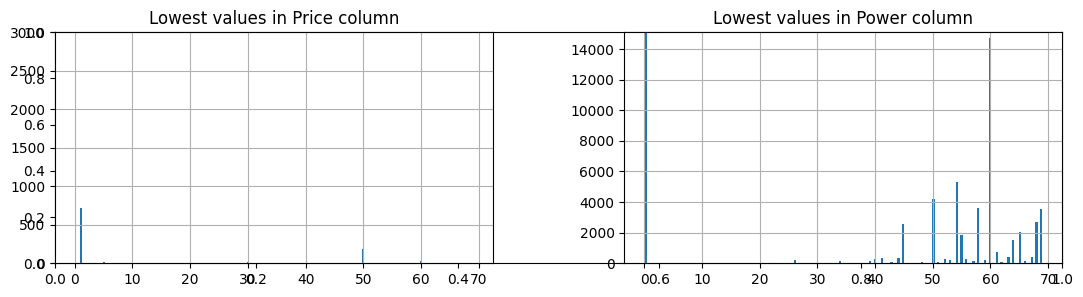

In [36]:
plt.subplots(figsize=(13, 3)) 

df[df['Price']<70].hist(column='Price',ax=plt.subplot(1,2, 1),bins = 280)
plt.title('Lowest values in Price column') 
plt.ylim(0,3000)

df[df['Power']<70].hist(column='Power',ax=plt.subplot(1, 2, 2),bins = 170)
plt.title('Lowest values in Power column') 
plt.ylim(0,15100)
plt.show() 

In [37]:
#delete values
df = df.loc[(df['Price']>60) & (df['Power']>30)]

df.describe()

,DateCrawled,Price,RegistrationYear,Power,Mileage,RegistrationMonth,DateCreated,PostalCode,LastSeen
count,288069.0,288069.000000,288069.000000,288069.000000,288069.000000,288069.000000,288069.000000,288069.000000,288069.0
mean,2016.0,4904.044149,2003.394169,124.386702,128552.846714,6.033079,2015.999920,51273.774575,2016.0
std,0.0,4608.329891,6.624654,187.355685,36390.058103,3.566548,0.008935,25751.126451,0.0
min,2016.0,65.000000,1910.000000,31.000000,5000.000000,0.000000,2015.000000,1067.000000,2016.0
25%,2016.0,1399.000000,1999.000000,78.000000,125000.000000,3.000000,2016.000000,30966.000000,2016.0
50%,2016.0,3250.000000,2003.000000,113.000000,150000.000000,6.000000,2016.000000,50321.000000,2016.0
75%,2016.0,7000.000000,2008.000000,150.000000,150000.000000,9.000000,2016.000000,72108.000000,2016.0
max,2016.0,20000.000000,2019.000000,20000.000000,150000.000000,12.000000,2016.000000,99998.000000,2016.0


In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 288069 entries, 2 to 354368
Data columns (total 14 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   DateCrawled        288069 non-null  int32 
 1   Price              288069 non-null  int64 
 2   VehicleType        288069 non-null  object
 3   RegistrationYear   288069 non-null  int64 
 4   Gearbox            288069 non-null  object
 5   Power              288069 non-null  int64 
 6   Mileage            288069 non-null  int64 
 7   RegistrationMonth  288069 non-null  int64 
 8   FuelType           288069 non-null  object
 9   Brand              288069 non-null  object
 10  NotRepaired        288069 non-null  object
 11  DateCreated        288069 non-null  int32 
 12  PostalCode         288069 non-null  int64 
 13  LastSeen           288069 non-null  int32 
dtypes: int32(3), int64(6), object(5)
memory usage: 29.7+ MB


In [39]:
print(round(df.shape[0] /df_initial_size*100,2),'% of the initial data is preserved')

81.29 % of the initial data is preserved


## Model features
### Numerical features

In [40]:
df.corr(numeric_only=True)

,DateCrawled,Price,RegistrationYear,Power,Mileage,RegistrationMonth,DateCreated,PostalCode,LastSeen
DateCrawled,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Price,NaN,1.000000,0.462309,0.140261,-0.397330,0.062129,-0.003911,0.063401,NaN
RegistrationYear,NaN,0.462309,1.000000,0.030079,-0.302457,0.022713,-0.000524,0.019630,NaN
Power,NaN,0.140261,0.030079,1.000000,0.024070,0.009467,0.000151,0.009550,NaN
Mileage,NaN,-0.397330,-0.302457,0.024070,1.000000,-0.016941,0.004609,-0.012362,NaN
RegistrationMonth,NaN,0.062129,0.022713,0.009467,-0.016941,1.000000,0.002806,0.002656,NaN
DateCreated,NaN,-0.003911,-0.000524,0.000151,0.004609,0.002806,1.000000,0.001626,NaN
PostalCode,NaN,0.063401,0.019630,0.009550,-0.012362,0.002656,0.001626,1.000000,NaN
LastSeen,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


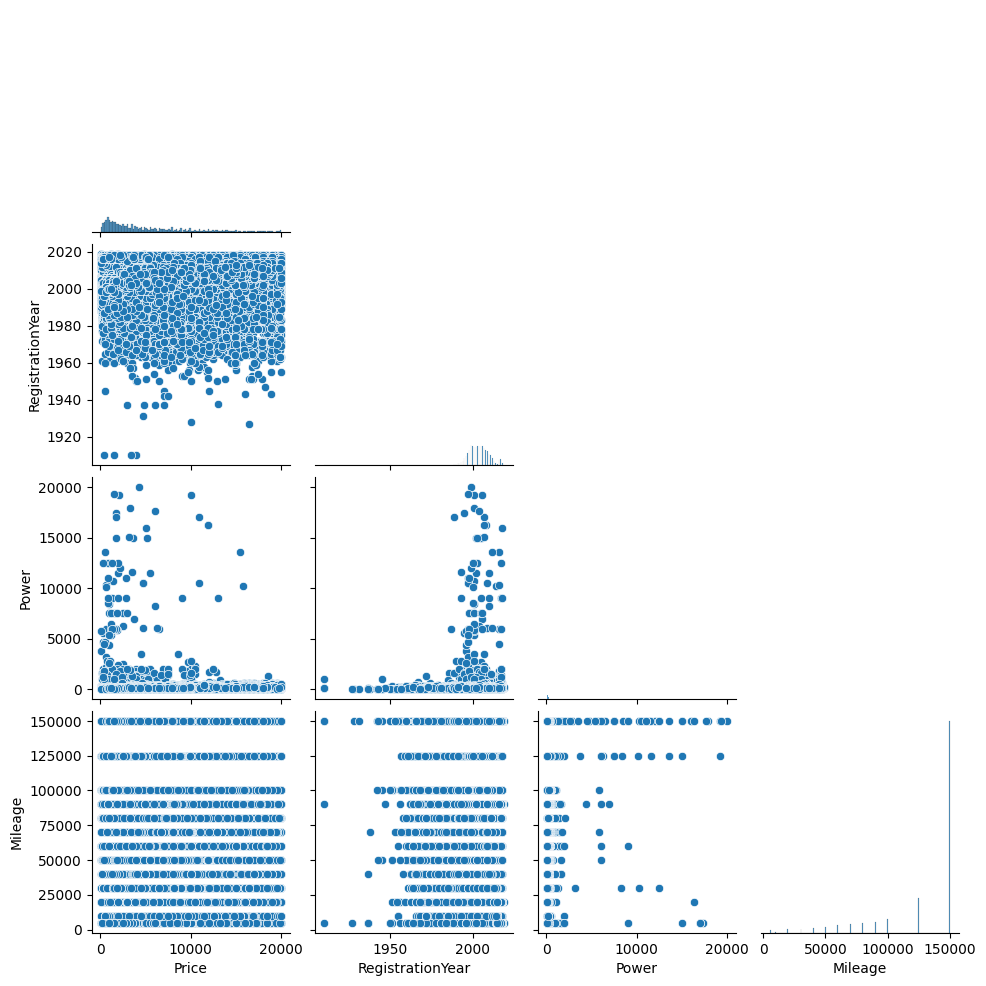

In [41]:
sns.pairplot(df.loc[:,['Price', 'RegistrationYear', 'Power', 'Mileage', 'NotRepaired']],corner=True)
plt.show()

### Categorical features

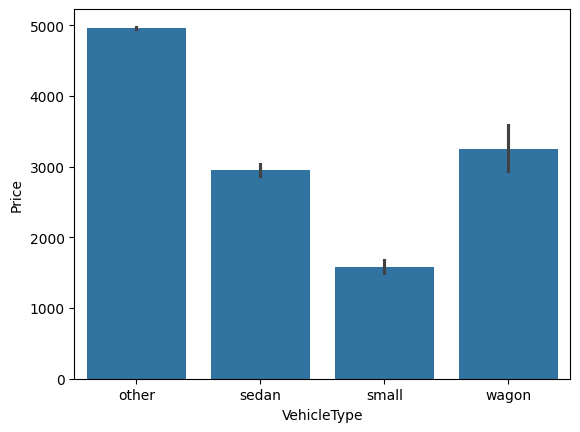

In [42]:
sns.barplot(data=df, x='VehicleType', y='Price')
plt.show()

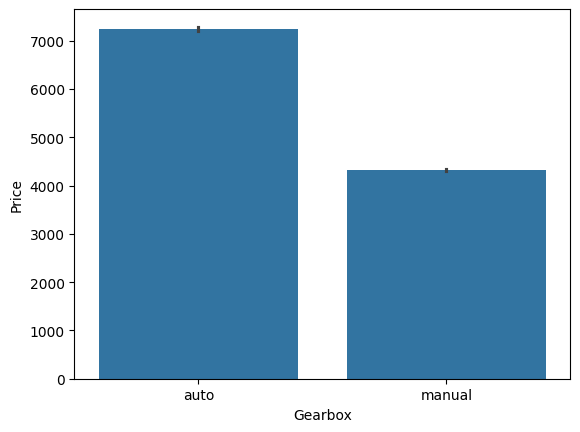

In [43]:
sns.barplot(data=df, x='Gearbox', y='Price')
plt.show()

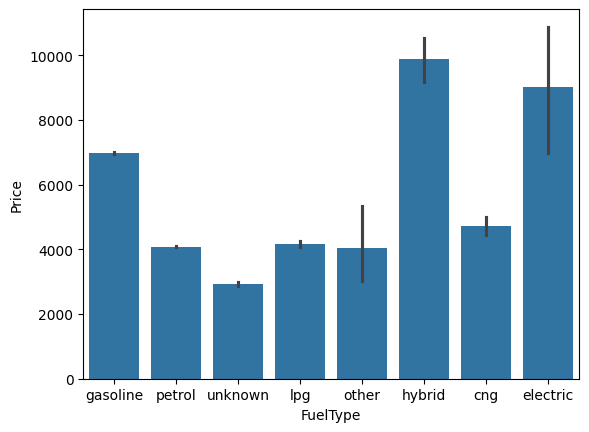

In [44]:
sns.barplot(data=df, x='FuelType', y='Price')
plt.show()

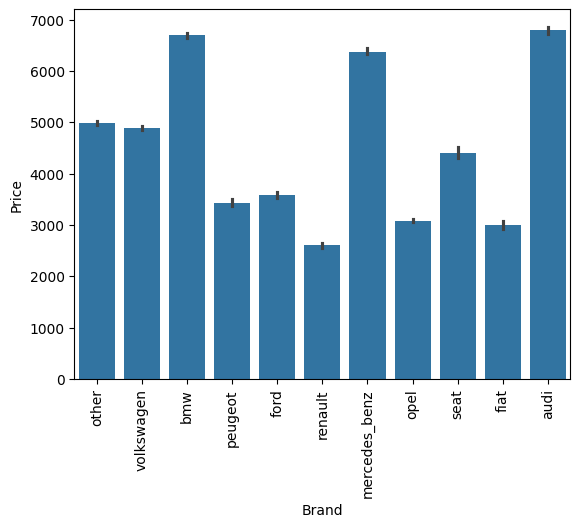

In [45]:
sns.barplot(data=df, x='Brand', y='Price')
plt.xticks(rotation='vertical')
plt.show()

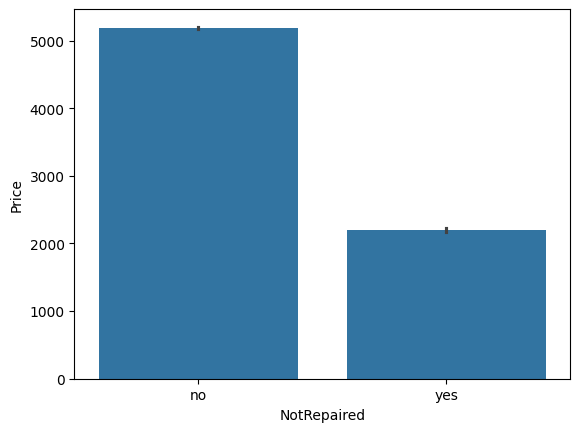

In [46]:
sns.barplot(data=df, x='NotRepaired', y='Price')
plt.show()

For all categorical characteristics, there are significant differences in the averages for each category, so these are taken into account.

Based on the previous analyses, the following data were selected to create the model:

**Target column:**
- `Price` - the selling price of the vehicle

**Features:**
- `VehicleType` - the vehicle's body type
- `RegistrationYear` - the vehicle's registration year
- `Gearbox` - the gearbox type
- `Power` - the power
- `Mileage` - the mileage (measured in km according to the regional specificities of the dataset)
- `FuelType` - the fuel type
- `Brand` - the vehicle's brand
- `NotRepaired` - the vehicle has or has not been repaired

## Model Training and Validation

Different models are compared using the **root mean square error (RMSE)** metric. Model speed is also analyzed.

The models analyzed are:
- Linear regression model (used as a basis for the sanity test)
- Decision tree model
- Random forest model
- LightGBM
- CatBoost
- XGBoost

**Preparing data to train and validate the models**

In [47]:
df.columns

Index(['DateCrawled', 'Price', 'VehicleType', 'RegistrationYear', 'Gearbox',
       'Power', 'Mileage', 'RegistrationMonth', 'FuelType', 'Brand',
       'NotRepaired', 'DateCreated', 'PostalCode', 'LastSeen'],
      dtype='object')

In [48]:
target = df['Price']
features = df.drop(['DateCrawled', 'Price', 'RegistrationMonth', 'DateCreated','PostalCode', 'LastSeen'], axis=1)

In [49]:
# split data (75% - 25%)
train_features, valid_features, train_target, valid_target = train_test_split(features, target,
                                                                        test_size=0.25, random_state=12345 )

In [50]:
#apply OHE
features_ohe = pd.get_dummies(features,drop_first=True) 

# split data (75% - 25%)
train_features_ohe, valid_features_ohe, train_target_ohe, valid_target_ohe = train_test_split(features_ohe, target,
                                                                              test_size=0.25, random_state=12345 )

In [51]:
#function to calculate training and prediction time
def train_and_pred_time(model,model_name,train_features, train_target,valid_features):
    #time before training
    start_time1 = time.time()
    
    #train model
    if model_name == 'cbr':
        model.fit(train_features)
    else: 
        model.fit(train_features, train_target)
    
    #time after training
    end_time1 = time.time()
    
    #training duration
    train_time = end_time1 - start_time1
    
    #time before the prediction
    start_time2 = time.time()
    
    #prediction of validation data
    predictions = model.predict(valid_features)
    
    #time after the prediction
    end_time2 = time.time()
    
    #prediction duration
    pred_time = end_time2 - start_time2
    
    return train_time, pred_time, predictions

### Linear Regression Model

In [52]:
model_lr = LinearRegression() 

lr_train_time, lr_pred_time, lr_pred = train_and_pred_time(model_lr, 'lr', train_features_ohe, train_target_ohe,
                                                           valid_features_ohe)

In [53]:
lr_train_rmse = round(mean_squared_error(train_target_ohe, model_lr.predict(train_features_ohe)),2)
lr_valid_rmse = round(mean_squared_error(valid_target_ohe,lr_pred),2)

print('RMSE training set:   ',lr_train_rmse) 
print('RMSE validation set: ',lr_valid_rmse) 

RMSE training set:    10372813.19
RMSE validation set:  10508270.42


**Linear regression model using stochastic gradient descent**

In [54]:
#Apply OHE
ohe = OneHotEncoder(drop='first', sparse_output=False)
train_features_encoded = ohe.fit_transform(train_features.select_dtypes(include=['object']))
valid_features_encoded = ohe.transform(valid_features.select_dtypes(include=['object']))


#scale data
scaler = StandardScaler()
train_features_scaled = scaler.fit_transform(train_features.select_dtypes(include=['number']))
valid_features_scaled = scaler.transform(valid_features.select_dtypes(include=['number']))

train_features_final = np.hstack((train_features_encoded, train_features_scaled))
valid_features_final = np.hstack((valid_features_encoded, valid_features_scaled))

In [55]:
model_sgd = SGDRegressor(max_iter=1000, tol=1e-3, random_state=12345)

sgd_train_time, sgd_pred_time, sgd_pred = train_and_pred_time(model_sgd, 'sgd', train_features_final, train_target,
                                                           valid_features_final)

In [56]:
sgd_train_rmse = round(mean_squared_error(train_target, model_lr.predict(train_features_final)),2)
sgd_valid_rmse = round(mean_squared_error(valid_target,sgd_pred),2)

print('RMSE training set:   ',sgd_train_rmse) 
print('RMSE validation set: ',sgd_valid_rmse) 

RMSE training set:    245315326587.86
RMSE validation set:  10535517.78


C:\Users\Usuario\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


The RMSE value of the first model performed better, it is used for comparison.

### Decision Tree Regressor

In [57]:
param_grid = {'max_depth': [1,2,4,6,8,10,15,20]}

tree_reg = DecisionTreeRegressor(random_state=12345)
grid_search = GridSearchCV(estimator=tree_reg, param_grid=param_grid, cv=5, verbose=True)
%time grid_search.fit(train_features_ohe, train_target_ohe)

final_model = grid_search.best_estimator_
final_model

Fitting 5 folds for each of 8 candidates, totalling 40 fits
CPU times: total: 21.4 s
Wall time: 24.3 s


,criterion,'squared_error'
,splitter,'best'
,max_depth,15
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,12345
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [58]:
model_dtr = DecisionTreeRegressor(random_state=12345, max_depth=15)

dtr_train_time, dtr_pred_time, dtr_pred = train_and_pred_time(model_dtr, 'dtr', train_features_ohe, train_target_ohe,
                                                           valid_features_ohe)

In [59]:
dtr_train_rmse = round(mean_squared_error(train_target_ohe, model_dtr.predict(train_features_ohe)),2)
dtr_valid_rmse = round(mean_squared_error(valid_target_ohe, dtr_pred),2)

print('RMSE training set:   ',dtr_train_rmse) 
print('RMSE validation set: ',dtr_valid_rmse) 

RMSE training set:    2592833.38
RMSE validation set:  3712084.25


### Random Forest Regressor

In [60]:
model_rfr =RandomForestRegressor(random_state=12345)
param_grid = {'n_estimators': [1,2,3,4,6,8,10],'max_features': [ 'sqrt', 'log2'],'max_depth' : [2,3,4,5,6,8,10]}
CV_rfr = GridSearchCV(estimator=model_rfr, param_grid=param_grid, cv= 5)
CV_rfr.fit(train_features_ohe,train_target_ohe)
CV_rfr.best_params_

{'max_depth': 10, 'max_features': 'sqrt', 'n_estimators': 10}

In [61]:
model_rfr = RandomForestRegressor(random_state=12345, max_depth=10, max_features= 'sqrt',n_estimators=10)

rfr_train_time, rfr_pred_time, rfr_pred = train_and_pred_time(model_rfr, 'rfr', train_features_ohe, train_target_ohe,
                                                           valid_features_ohe)

In [62]:
rfr_train_rmse = round(mean_squared_error(train_target_ohe, model_rfr.predict(train_features_ohe) ),2)
rfr_valid_rmse = round(mean_squared_error(valid_target_ohe, rfr_pred),2)

print('RMSE training set:   ', rfr_train_rmse) 
print('RMSE validation set: ', rfr_valid_rmse) 

RMSE training set:    4688229.51
RMSE validation set:  4836478.22


### LightGBM

In [63]:
# first configuration
model_ltb1= ltb.LGBMRegressor(boosting_type='gbdt',num_leaves=31, max_depth=-1, 
                              learning_rate=0.1, n_estimators=100, verbose=-1)

ltb_train_time1, ltb_pred_time1, ltb_pred1 = train_and_pred_time(model_ltb1, 'ltb', train_features_ohe, train_target_ohe,
                                                           valid_features_ohe)

Exception in thread Thread-5 (_readerthread):
Traceback (most recent call last):
  File "c:\ProgramData\anaconda3\envs\py_clean\Lib\threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "C:\Users\Usuario\AppData\Roaming\Python\Python312\site-packages\ipykernel\ipkernel.py", line 766, in run_closure
    _threading_Thread_run(self)
  File "c:\ProgramData\anaconda3\envs\py_clean\Lib\threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "c:\ProgramData\anaconda3\envs\py_clean\Lib\subprocess.py", line 1599, in _readerthread
    buffer.append(fh.read())
                  ^^^^^^^^^
  File "<frozen codecs>", line 322, in decode
UnicodeDecodeError: 'utf-8' codec can't decode byte 0xa2 in position 108: invalid start byte


In [64]:
ltb1_train_rmse = round(mean_squared_error(train_target, model_ltb1.predict(train_features_ohe) ),2)
ltb1_valid_rmse = round(mean_squared_error(valid_target, ltb_pred1),2)

print('RMSE training set:   ', ltb1_train_rmse) 
print('RMSE validation set: ', ltb1_valid_rmse) 

RMSE training set:    3383202.17
RMSE validation set:  3478602.87


In [65]:
# second configuration
model_ltb2=ltb.LGBMRegressor(boosting_type='gbdt',num_leaves=20, max_depth=10, learning_rate=0.05, n_estimators=100)

ltb_train_time2, ltb_pred_time2, ltb_pred2 = train_and_pred_time(model_ltb2, 'ltb', train_features_ohe, train_target_ohe,
                                                           valid_features_ohe)

In [66]:
ltb2_train_rmse = round(mean_squared_error(train_target_ohe, model_ltb2.predict(train_features_ohe) ),2)
ltb2_valid_rmse = round(mean_squared_error(valid_target_ohe, ltb_pred2 ),2)

print('RMSE training set:   ', ltb2_train_rmse) 
print('RMSE validation set: ', ltb2_valid_rmse) 

RMSE training set:    3813317.11
RMSE validation set:  3851244.06


The first parameters result in a lower RMSE result, therefore, this model is considered the best of the two.

### CatBoost

OHE is not required

In [67]:
train_features.info()

<class 'pandas.core.frame.DataFrame'>
Index: 216051 entries, 316635 to 267686
Data columns (total 8 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   VehicleType       216051 non-null  object
 1   RegistrationYear  216051 non-null  int64 
 2   Gearbox           216051 non-null  object
 3   Power             216051 non-null  int64 
 4   Mileage           216051 non-null  int64 
 5   FuelType          216051 non-null  object
 6   Brand             216051 non-null  object
 7   NotRepaired       216051 non-null  object
dtypes: int64(3), object(5)
memory usage: 14.8+ MB


In [68]:
#identify categorical columns
categorical_features_index = [0,2,5,6,7]
train_data = Pool(data = train_features, label = train_target, cat_features = categorical_features_index)

model_cbr = CatBoostRegressor(iterations=100, random_seed=123456, verbose=False)

cbr_train_time, cbr_pred_time, cbr_pred = train_and_pred_time(model_cbr, 'cbr', train_data, train_target, valid_features)

In [69]:
cbr_train_rmse = round(mean_squared_error(train_target, model_cbr.predict(train_features) ),2)
cbr_valid_rmse = round(mean_squared_error(valid_target, model_cbr.predict(valid_features) ),2)

print('RMSE training set:   ', cbr_train_rmse) 
print('RMSE validation set: ', cbr_valid_rmse)

RMSE training set:    3244843.24
RMSE validation set:  3366862.96


### XGBoost

In [70]:
# first configuration
model_xgbr1 = xg.XGBRegressor(booster ='gblinear', objective ='reg:squarederror', n_estimators = 50, seed = 12345)

xgbr_train_time1, xgbr_pred_time1, xgbr_pred1= train_and_pred_time(model_xgbr1, 'xgbr', train_features_ohe, 
                                                                   train_target_ohe, valid_features_ohe)

In [71]:
xgbr_train_rmse1 = round(mean_squared_error(train_target_ohe, model_xgbr1.predict(train_features_ohe) ),2)
xgbr_valid_rmse1 = round(mean_squared_error(valid_target_ohe, model_xgbr1.predict(valid_features_ohe) ),2)

print('RMSE training set:   ', xgbr_train_rmse1) 
print('RMSE validation set: ', xgbr_valid_rmse1) 

RMSE training set:    12618257.0
RMSE validation set:  12677989.0


In [72]:
# second configuration
model_xgbr2 = xg.XGBRegressor(booster ='gblinear', objective ='reg:squarederror', n_estimators = 100, seed = 12345,)

xgbr_train_time2, xgbr_pred_time2, xgbr_pred2= train_and_pred_time(model_xgbr2, 'xgbr', train_features_ohe, 
                                                                   train_target_ohe, valid_features_ohe)

In [73]:
xgbr_train_rmse2 = round(mean_squared_error(train_target_ohe, model_xgbr2.predict(train_features_ohe) ),2)
xgbr_valid_rmse2 = round(mean_squared_error(valid_target_ohe, model_xgbr2.predict(valid_features_ohe) ),2)

print('RMSE training set:   ', xgbr_train_rmse2) 
print('RMSE validation set: ', xgbr_valid_rmse2)

RMSE training set:    12385950.0
RMSE validation set:  12429853.0



The second parameters result in a lower RMSE result, therefore, this model is considered the best of the two.

## Compare results

In [74]:
table = pd.DataFrame({'Model':['Linear Regression','Decision Tree Regressor','Random Forest Regressor',
                               'LGBM Regressor','CatBoost Regressor','XGB Regressor'],
'Training time (s)': [lr_train_time, dtr_train_time, rfr_train_time, ltb_train_time1, cbr_train_time, xgbr_train_time2],
'Prediction_time (ms)': [lr_pred_time, dtr_pred_time, rfr_pred_time, ltb_pred_time1, cbr_pred_time, xgbr_pred_time2],
'RMSE training set': [lr_train_rmse, dtr_train_rmse, rfr_train_rmse, ltb1_train_rmse, cbr_train_rmse, xgbr_train_rmse2],
'RMSE validation set': [lr_valid_rmse, dtr_valid_rmse, rfr_valid_rmse, ltb1_valid_rmse, cbr_valid_rmse,  xgbr_valid_rmse2]})

table.sort_values('Training time (s)')

,Model,Training time (s),Prediction_time (ms),RMSE training set,RMSE validation set
0,Linear Regression,0.254389,0.025307,10372813.19,10508270.42
1,Decision Tree Regressor,1.386300,0.021209,2592833.38,3712084.25
2,Random Forest Regressor,2.001060,0.095985,4688229.51,4836478.22
3,LGBM Regressor,3.955633,0.313317,3383202.17,3478602.87
5,XGB Regressor,6.972794,0.066720,12385950.00,12429853.00
4,CatBoost Regressor,10.000767,0.320362,3244843.24,3366862.96


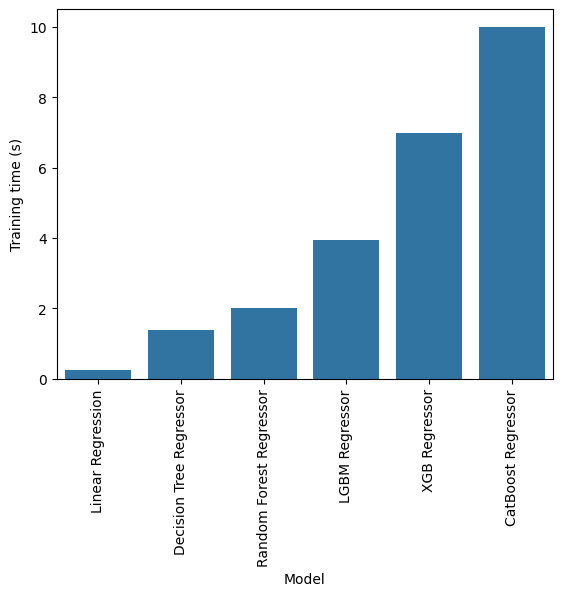

In [75]:
sns.barplot(data=table.sort_values('Training time (s)'),x='Model',y='Training time (s)')
plt.xticks(rotation='vertical')
plt.show()

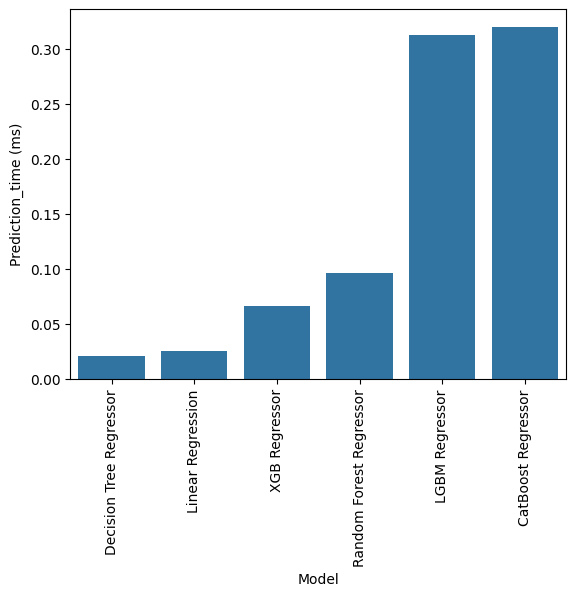

In [76]:
sns.barplot(data=table.sort_values('Prediction_time (ms)'),x='Model',y='Prediction_time (ms)')
plt.xticks(rotation='vertical')
plt.show()

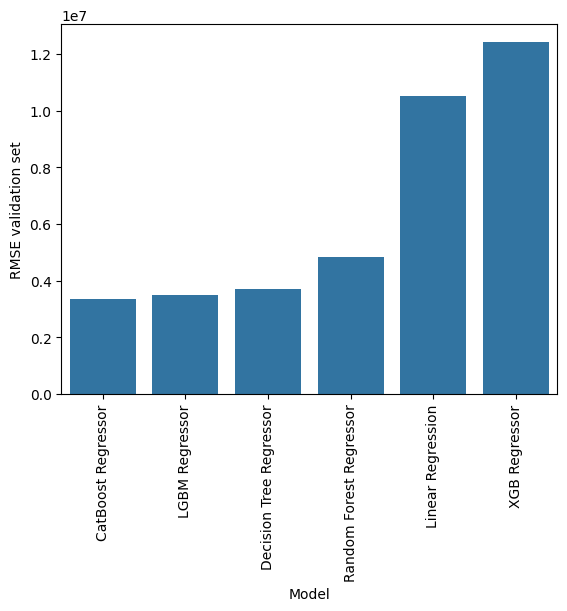

In [77]:
sns.barplot(data=table.sort_values('RMSE validation set'),x='Model',y='RMSE validation set')
plt.xticks(rotation='vertical')
plt.show()

## Conclusiones

Considering that the parameters of interest are:
- Training time
- Prediction speed
- Prediction quality

Comparing training times, the best are:
1. Linear regression
2. Regression tree
3. Regression forest

The CatBoost model has the longest training time, even doubling the time of other models.

Comparing prediction times, the best are:
1. Regression tree
2. XGBoost model
3. Regression forest

Analyzing prediction quality, the best are:
1. CatBoost model
2. LightGBM model
3. Regression tree

Based on model quality, the CatBoost model has a very high training time compared to the other models, and the LightGBM model has a high prediction time and a high RMSE value. This rules them out as the best models.

When searching for a model with good performance across all parameters of interest, the use of the **regression tree** is recommended as it always appears in the top 3 for the parameters of interest.